# Decision Trees and random forests

In [2]:
import pandas as pd
df = pd.read_csv("C:/Users/DELL/Desktop/Machine Learning/ML from youtube/data/whether.csv").drop(["Date"], axis = 1)
df

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,ENE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,N,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,WNW,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,N,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


In [3]:
df['RainTomorrow'].isna().sum()

np.int64(3267)

In [4]:
df.dropna(subset=['RainTomorrow'], inplace=True)

Identify input and target columns

In [5]:
input_col = df.drop('RainTomorrow', axis=1).columns.tolist()
target_col = 'RainTomorrow'


Identify numerical and categorical columns


In [6]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.drop(columns = ["RainTomorrow"], axis = 1).select_dtypes(include=['object']).columns.tolist()
categorical_cols

['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

Impute (fill) missing numenc values

In [7]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
df[numerical_cols] = imputer.fit_transform(df[numerical_cols])

Scale numeric values to the (0, l) range

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(df[numerical_cols])
df[numerical_cols] = scaler.transform(df[numerical_cols])
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,1.421930e+05,1.421930e+05,142193.000000,1.421930e+05,1.421930e+05,1.421930e+05,1.421930e+05,1.421930e+05,1.421930e+05,1.421930e+05,1.421930e+05,1.421930e+05,1.421930e+05,1.421930e+05,1.421930e+05,1.421930e+05
mean,-1.279240e-16,-2.302632e-16,0.000000,1.982822e-16,1.694993e-16,-1.854898e-16,1.279240e-17,9.594298e-18,1.407164e-16,-6.716009e-17,1.878564e-14,1.537646e-14,-1.439145e-16,-4.189510e-16,-3.581871e-16,-1.023392e-16
std,1.000004e+00,1.000004e+00,1.000004,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00
min,-3.237865e+00,-3.942143e+00,-0.278989,-1.726530e+00,-2.787964e+00,-2.586651e+00,-1.581958e+00,-2.136964e+00,-3.636371e+00,-2.507433e+00,-5.507341e+00,-5.710798e+00,-1.947782e+00,-2.139575e+00,-3.737171e+00,-3.942400e+00
25%,-7.178699e-01,-7.492457e-01,-0.278989,-4.639446e-01,0.000000e+00,-6.838225e-01,-7.910912e-01,-6.463983e-01,-6.255971e-01,-7.053678e-01,-6.157160e-01,-6.372873e-01,-6.308796e-01,-2.390681e-01,-7.242591e-01,-7.258651e-01
50%,-2.917555e-02,-7.409551e-02,-0.278989,2.803502e-16,0.000000e+00,-7.491751e-02,-1.132055e-01,0.000000e+00,6.107062e-02,0.000000e+00,3.370384e-14,1.701449e-14,0.000000e+00,-4.219974e-16,-2.897164e-02,-5.635995e-02
75%,7.221273e-01,6.995141e-01,-0.184013,2.803502e-16,3.931185e-01,4.578744e-01,5.646801e-01,6.148497e-01,7.477383e-01,6.583576e-01,6.146018e-01,6.198657e-01,6.860233e-01,7.111855e-01,6.972175e-01,6.713630e-01
max,3.398644e+00,3.498574e+00,43.766096,4.404218e+01,2.513840e+00,7.231942e+00,1.310556e+01,7.838361e+00,1.645688e+00,2.363014e+00,3.460638e+00,3.643019e+00,2.002926e+00,2.136566e+00,3.586523e+00,3.640473e+00


Performing the encoding

In [9]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore') 
encoder.fit(df[categorical_cols])
encoded_cols = encoder.get_feature_names_out(categorical_cols).tolist()
encoded_df = pd.DataFrame(encoder.transform(df[categorical_cols]), columns=encoded_cols, index = df.index)
encoded_df

,Location_Adelaide,Location_Albany,Location_Albury,Location_AliceSprings,Location_BadgerysCreek,Location_Ballarat,Location_Bendigo,Location_Brisbane,Location_Cairns,Location_Canberra,...,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,WindDir3pm_nan,RainToday_No,RainToday_Yes,RainToday_nan
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
145455,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
145456,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
145457,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [10]:
pd.set_option('display.max_columns', None)
data = pd.concat([df, encoded_df], axis=1)
data

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Location_Adelaide,Location_Albany,Location_Albury,Location_AliceSprings,Location_BadgerysCreek,Location_Ballarat,Location_Bendigo,Location_Brisbane,Location_Cairns,Location_Canberra,Location_Cobar,Location_CoffsHarbour,Location_Dartmoor,Location_Darwin,Location_GoldCoast,Location_Hobart,Location_Katherine,Location_Launceston,Location_Melbourne,Location_MelbourneAirport,Location_Mildura,Location_Moree,Location_MountGambier,Location_MountGinini,Location_Newcastle,Location_Nhil,Location_NorahHead,Location_NorfolkIsland,Location_Nuriootpa,Location_PearceRAAF,Location_Penrith,Location_Perth,Location_PerthAirport,Location_Portland,Location_Richmond,Location_Sale,Location_SalmonGums,Location_Sydney,Location_SydneyAirport,Location_Townsville,Location_Tuggeranong,Location_Uluru,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera,WindGustDir_E,WindGustDir_ENE,WindGustDir_ESE,WindGustDir_N,WindGustDir_NE,WindGustDir_NNE,WindGustDir_NNW,WindGustDir_NW,WindGustDir_S,WindGustDir_SE,WindGustDir_SSE,WindGustDir_SSW,WindGustDir_SW,WindGustDir_W,WindGustDir_WNW,WindGustDir_WSW,WindGustDir_nan,WindDir9am_E,WindDir9am_ENE,WindDir9am_ESE,WindDir9am_N,WindDir9am_NE,WindDir9am_NNE,WindDir9am_NNW,WindDir9am_NW,WindDir9am_S,WindDir9am_SE,WindDir9am_SSE,WindDir9am_SSW,WindDir9am_SW,WindDir9am_W,WindDir9am_WNW,WindDir9am_WSW,WindDir9am_nan,WindDir3pm_E,WindDir3pm_ENE,WindDir3pm_ESE,WindDir3pm_N,WindDir3pm_NE,WindDir3pm_NNE,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,WindDir3pm_nan,RainToday_No,RainToday_Yes,RainToday_nan
0,Albury,0.189954,-0.045964,-0.207757,2.803502e-16,0.0,W,0.305648,W,WNW,0.677661,0.614850,0.113891,-1.435935,-1.475456,-1.220966,1.563959,-4.219974e-16,-0.013521,0.016412,No,No,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,Albury,-0.749174,0.263480,-0.278989,2.803502e-16,0.0,WNW,0.305648,NNW,WSW,-1.130034,0.385532,-1.312265,-1.289821,-1.045586,-1.116203,0.000000,-4.219974e-16,0.032832,0.380274,No,No,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,Albury,0.111694,0.347873,-0.278989,2.803502e-16,0.0,WSW,0.457874,W,WSW,0.564680,0.844167,-1.629188,-1.046299,-1.490279,-0.981508,0.000000,-1.189322e+00,0.619963,0.220175,No,No,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,Albury,-0.467436,0.671383,-0.278989,2.803502e-16,0.0,NE,-1.216614,SE,E,-0.339167,-1.105034,-1.259444,-1.728162,-0.007969,-0.367897,0.000000,-4.219974e-16,0.171889,0.700472,No,No,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

In [11]:
data.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Location_Adelaide,Location_Albany,Location_Albury,Location_AliceSprings,Location_BadgerysCreek,Location_Ballarat,Location_Bendigo,Location_Brisbane,Location_Cairns,Location_Canberra,Location_Cobar,Location_CoffsHarbour,Location_Dartmoor,Location_Darwin,Location_GoldCoast,Location_Hobart,Location_Katherine,Location_Launceston,Location_Melbourne,Location_MelbourneAirport,Location_Mildura,Location_Moree,Location_MountGambier,Location_MountGinini,Location_Newcastle,Location_Nhil,Location_NorahHead,Location_NorfolkIsland,Location_Nuriootpa,Location_PearceRAAF,Location_Penrith,Location_Perth,Location_PerthAirport,Location_Portland,Location_Richmond,Location_Sale,Location_SalmonGums,Location_Sydney,Location_SydneyAirport,Location_Townsville,Location_Tuggeranong,Location_Uluru,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera,WindGustDir_E,WindGustDir_ENE,WindGustDir_ESE,WindGustDir_N,WindGustDir_NE,WindGustDir_NNE,WindGustDir_NNW,WindGustDir_NW,WindGustDir_S,WindGustDir_SE,WindGustDir_SSE,WindGustDir_SSW,WindGustDir_SW,WindGustDir_W,WindGustDir_WNW,WindGustDir_WSW,WindGustDir_nan,WindDir9am_E,WindDir9am_ENE,WindDir9am_ESE,WindDir9am_N,WindDir9am_NE,WindDir9am_NNE,WindDir9am_NNW,WindDir9am_NW,WindDir9am_S,WindDir9am_SE,WindDir9am_SSE,WindDir9am_SSW,WindDir9am_SW,WindDir9am_W,WindDir9am_WNW,WindDir9am_WSW,WindDir9am_nan,WindDir3pm_E,WindDir3pm_ENE,WindDir3pm_ESE,WindDir3pm_N,WindDir3pm_NE,WindDir3pm_NNE,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,WindDir3pm_nan,RainToday_No,RainToday_Yes,RainToday_nan
count,1.421930e+05,1.421930e+05,142193.000000,1.421930e+05,1.421930e+05,1.421930e+05,1.421930e+05,1.421930e+05,1.421930e+05,1.421930e+05,1.421930e+05,1.421930e+05,1.421930e+05,1.421930e+05,1.421930e+05,1.421930e+05,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.00000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000
mean,-1.279240e-16,-2.302632e-16,0.000000,1.982822e-16,1.694993e-16,-1.854898e-16,1.279240e-17,9.594298e-18,1.407164e-16,-6.716009e-17,1.878564e-14,1.537646e-14,-1.439145e-16,-4.189510e-16,-3.581871e-16,-1.023392e-16,0.021731,0.021211,0.021175,0.021316,0.020592,0.021295,0.021337,0.022230,0.021014,0.024038,0.021014,0.020768,0.020697,0.022448,0.020957,0.022420,0.010964,0.021295,0.017125,0.021161,0.021147,0.020071,0.021309,0.020444,0.020782,0.011034,0.020599,0.020845,0.021

training testing and splitting the data

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data[numerical_cols+encoded_cols], data[target_col], test_size=0.2, random_state=42)

In [13]:
encoded_cols

['Location_Adelaide',
 'Location_Albany',
 'Location_Albury',
 'Location_AliceSprings',
 'Location_BadgerysCreek',
 'Location_Ballarat',
 'Location_Bendigo',
 'Location_Brisbane',
 'Location_Cairns',
 'Location_Canberra',
 'Location_Cobar',
 'Location_CoffsHarbour',
 'Location_Dartmoor',
 'Location_Darwin',
 'Location_GoldCoast',
 'Location_Hobart',
 'Location_Katherine',
 'Location_Launceston',
 'Location_Melbourne',
 'Location_MelbourneAirport',
 'Location_Mildura',
 'Location_Moree',
 'Location_MountGambier',
 'Location_MountGinini',
 'Location_Newcastle',
 'Location_Nhil',
 'Location_NorahHead',
 'Location_NorfolkIsland',
 'Location_Nuriootpa',
 'Location_PearceRAAF',
 'Location_Penrith',
 'Location_Perth',
 'Location_PerthAirport',
 'Location_Portland',
 'Location_Richmond',
 'Location_Sale',
 'Location_SalmonGums',
 'Location_Sydney',
 'Location_SydneyAirport',
 'Location_Townsville',
 'Location_Tuggeranong',
 'Location_Uluru',
 'Location_WaggaWagga',
 'Location_Walpole',
 'Locat

##### Creating and training a model


a hyperparameter for decision trees is `max_depth` and we have to tune it to have the maximum depth of the tree to be adjusted according to our chioce

In [14]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=5,random_state=42)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [15]:
model.predict(X_train)

array(['No', 'Yes', 'No', ..., 'No', 'No', 'No'],
      shape=(113754,), dtype=object)

In [16]:
from sklearn.metrics import accuracy_score
accuracy_score(y_train, model.predict(X_train))

0.839064999912091

In [17]:
accuracy_score(y_test, model.predict(X_test))

0.8360350223284926

In [18]:
def max_depth(depth):
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    train_err = 1 - accuracy_score(y_train, model.predict(X_train))
    test_err = 1 - accuracy_score(y_test, model.predict(X_test))
    # print(f"The max depth is {depth}, Train Accuracy is {(train_acc*100):.2f}%, Test Accuracy is {(test_acc*100):.2f}%")
    # return train_acc, test_acc
    return {"max depth":depth,"training data" : train_err, "test data" : test_err}

In [19]:
max_depth(3)

{'max depth': 3,
 'training data': 0.17098299840005626,
 'test data': 0.17286121171630509}

In [20]:
max_depth(3)

{'max depth': 3,
 'training data': 0.17098299840005626,
 'test data': 0.17286121171630509}

In [21]:
max_depth(10)

{'max depth': 10,
 'training data': 0.1369358440142764,
 'test data': 0.1629452512394951}

In [22]:
max_depth(11)

{'max depth': 11,
 'training data': 0.1283295532464792,
 'test data': 0.1628045993178382}

In [23]:
errors_df = pd.DataFrame([max_depth(i) for i in range(1,21)])
errors_df

,max depth,training data,test data
0,1,0.184248,0.187313
1,2,0.179370,0.180281
2,3,0.170983,0.172861
3,4,0.166473,0.170716
4,5,0.160935,0.163965
5,6,0.158069,0.163859
6,7,0.153480,0.160976
7,8,0.149454,0.161679
8,9,0.144056,0.163156
9,10,0.136936,0.162945


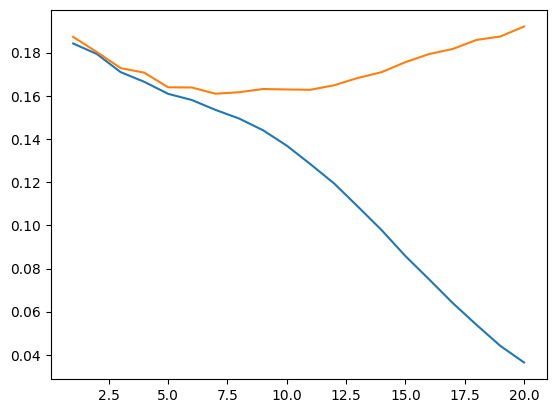

In [24]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(errors_df["max depth"], errors_df["training data"], label="Training Error")
plt.plot(errors_df["max depth"], errors_df["test data"], label="Testing Error")
plt.show()

### Moving towards random forrests

In [25]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
model.predict(X_test)

array(['Yes', 'No', 'No', ..., 'No', 'No', 'No'],
      shape=(28439,), dtype=object)

In [27]:
model.predict(X_test)

array(['Yes', 'No', 'No', ..., 'No', 'No', 'No'],
      shape=(28439,), dtype=object)

In [28]:
accuracy_score(y_test, model.predict(X_test))

0.8528429269664897

In [29]:
accuracy_score(y_train, model.predict(X_train))

0.9999120910033933

we can aso create a dataframe to jusdge the importance of each feature in the dataset using feature_importance_ attribute of the model

In [30]:
importance = pd.DataFrame({
    'features' : X_train.columns,
    'importance' : model.feature_importances_
}).sort_values(by='importance', ascending=False)
importance

,features,importance
9,Humidity3pm,0.135134
11,Pressure3pm,0.054128
2,Rainfall,0.050129
8,Humidity9am,0.049839
10,Pressure9am,0.049540
...,...,...
29,Location_Darwin,0.000715
55,Location_Townsville,0.000711
19,Location_AliceSprings,0.000703
32,Location_Katherine,0.000513


tuning the hyperparameters for random forests:

In [40]:
def testing_params(**params):
    model = RandomForestClassifier(random_state=42, n_jobs=-1, **params)
    model.fit(X_train, y_train)
    test_pred = model.predict(X_test)
    train_pred = model.predict(X_train)
    return accuracy_score(y_train, train_pred), accuracy_score(y_test, test_pred)

`n_estimators`: No of trees withon the forrest you want to divide , By default 100

In [41]:
testing_params(n_estimators = 10)

(0.9869543049035638, 0.8395513203699145)

In [42]:
testing_params(n_estimators = 300)

(0.9999648364013574, 0.8529484159077323)

`max_features` is used to tell the fsashion of the features being picked

In [43]:
testing_params(max_features='log2')

(0.9999384637023753, 0.8513660817890925)

In [44]:
testing_params(max_features = 'log2', n_estimators=300)

(0.9999648364013574, 0.8520341784169626)

max_depth and max_leaf_nodes


In [45]:
testing_params(max_depth = 5)

(0.8202436837385938, 0.817398642708956)

In [46]:
testing_params(max_leaf_nodes=10)

(0.8066089983648926, 0.8054432293681213)

` leaf ` is a very last node which is not the parent of any node


`max_sample_leaf` <br><br>
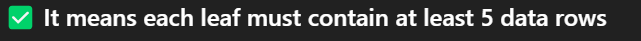

`max_sample_split` 

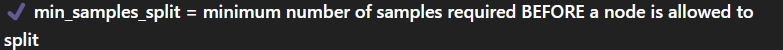

In [51]:
testing_params(min_samples_leaf = 5, min_samples_split = 7)

(0.9032297765353307, 0.8511551039066071)

`min_impurity_decrease` is the way to get to know how much the data is mixed up

In [54]:
testing_params(min_impurity_decrease=1)

(0.7755155862650984, 0.7770315411934315)

In [56]:
testing_params(min_impurity_decrease = 1e-20)

(0.9999120910033933, 0.8528429269664897)

`Bootstrap` and `max_samples` 
when bootstrap is set to True the another trees in the forrest can choose the different rows as and max_samples allows you to have maximum rows according to which split each time
 

In [58]:
testing_params(bootstrap = True, max_samples=0.8)

(0.998769274047506, 0.8530890678293892)

`class_weight` is used to determine the weight of rows in a specific category it's important because naturally weight is greater for the one which has more data. Weight can be used to calculating gini and spliting whatsoever


In [59]:
testing_params(class_weight='balanced')

(0.999920881903054, 0.8514364077499209)

### Putting it all together

In [ ]:
complete_model = RandomForestClassifier(random_state = 42, n_jobs = -1, n_estimators=300, max_features=7, max_depth=30, class_weight={'No' : 1, 'Yes' : 2})

In [65]:
complete_model.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,30
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,7
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [66]:
complete_model.score(X_train, y_train), complete_model.score(X_test, y_test)

(0.992431035392162, 0.8538626533985021)